# 11 — Checkpoints de campaña y memoria inter-campaña

El requisito de producto: **un productor tiene que poder consultar el modelo en cualquier
momento** — antes de sembrar o en cualquier punto de la campaña — y obtener una predicción
que use toda la información disponible *hasta ese momento*, más la historia de su zona.

Eso separa el problema en dos ejes independientes:

- **Intra-campaña**: ¿en qué punto del calendario estoy? Determina qué meses de clima ya
  se observaron y cuáles todavía no.
- **Inter-campaña**: ¿qué viene pasando en esta zona? Una memoria de campañas anteriores
  con más peso en lo reciente.

Este notebook resuelve el primero (5 checkpoints, un modelo por cada uno) y **mide que el
segundo ya estaba resuelto** por las features autorregresivas que el repo tenía.

In [1]:
import os, sys, json, warnings
sys.path.insert(0, os.path.abspath(".."))     # componente_b/ (import plano, como el resto)
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

import datos, evaluacion as ev, momentum as mom
from modelos.xgboost_model import XGBoostRegressor

CULTIVOS = ["soja", "maiz"]
SEEDS = [42, 52, 62]
HP = json.load(open("retuning_cv_honesta.json"))

# Configuración común a todos los checkpoints. use_agro queda en False a propósito:
# las ventanas críticas agronómicas llegan a marzo, así que solo existirían en 'full'
# y romperían la comparabilidad entre checkpoints.
BASE = dict(use_suelo=True, use_lags=3, enc_smooth=10.0)
print("checkpoints:", list(datos.CHECKPOINTS))

checkpoints: ['pre_siembra', 'nov', 'ene', 'pre_cosecha', 'full']


## 1 — Qué observa cada checkpoint

Cada checkpoint se define por su **mes de corte**: el último mes cuyo clima ya ocurrió.
Las columnas de meses posteriores se **excluyen**, no se imputan. La regla aprovecha que
todas las columnas mensuales del panel llevan sufijo `_sep` … `_mar`.

Las estacionales de ERA5 no tienen sufijo de mes y se declaran a mano: `sm_winter`
(Jun–Ago) está disponible siempre, `sm_planting` y `frost_days_early` (Sep–Nov) desde
noviembre, y `frost_days` (Sep–Mar) recién con la campaña terminada.

**Excepción declarada — ONI.** Se mantiene en todos los checkpoints, incluso pre-siembra,
donde `oni_ene`/`oni_feb` todavía no ocurrieron. Es la convención que ya traía el repo y se
sostiene porque en producción ese valor sería el *pronóstico* de ENSO, disponible por
adelantado. Es la única concesión de información futura del esquema.

In [2]:
panel = datos.load_panel()
_, _, _, clim, _ = datos.crop_frame(panel, "soja")

filas = []
for m, corte in datos.CHECKPOINTS.items():
    cols = datos._filter_momento(clim, m)
    meses = [x for x in datos.MESES
             if any(c.endswith(f"_{x}") and not c.startswith("oni_") for c in cols)]
    filas.append({"checkpoint": m, "mes de corte": corte or "—",
                  "cols climáticas": len(cols),
                  "meses observados": ", ".join(meses) or "—"})
pd.DataFrame(filas).set_index("checkpoint")

[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


,mes de corte,cols climáticas,meses observados
checkpoint,,,
pre_siembra,—,6,—
nov,nov,35,"sep, oct, nov"
ene,ene,53,"sep, oct, nov, dic, ene"
pre_cosecha,feb,62,"sep, oct, nov, dic, ene, feb"
full,mar,72,"sep, oct, nov, dic, ene, feb, mar"


In [3]:
# Dos invariantes que no pueden romperse.
for m, corte in datos.CHECKPOINTS.items():
    cols = datos._filter_momento(clim, m)
    hasta = -1 if corte is None else datos.MESES.index(corte)
    futuras = [c for c in cols if not c.startswith("oni_")
               and c.rsplit("_", 1)[-1] in datos.MESES
               and datos.MESES.index(c.rsplit("_", 1)[-1]) > hasta]
    assert not futuras, f"{m}: se filtraron meses futuros {futuras}"

prev = None
for m in datos.CHECKPOINTS:
    cols = set(datos._filter_momento(clim, m))
    assert prev is None or prev <= cols, f"{m} no contiene al checkpoint anterior"
    prev = cols
print("OK — ningún mes futuro se filtra y cada checkpoint contiene al anterior")

OK — ningún mes futuro se filtra y cada checkpoint contiene al anterior


## 2 — Eje inter-campaña: el momentum no aporta

El spec propone resumir la historia con un EWMA de factor `gamma`:
`M_t = gamma·M_(t-1) + (1-gamma)·x_t`, con la feature de la campaña `t` construida **solo
con campañas estrictamente anteriores**.

Pero el repo ya tenía `use_lags`, que agrega `rinde_lag1..k` y `rinde_ma5`. La pregunta
honesta no es "¿el momentum sirve?" sino **"¿aporta algo sobre lo que ya hay?"**.

In [4]:
def cv(cultivo, **kw):
    p = dict(HP[cultivo]["xgb"]["best_params"])
    ds = datos.prepare(cultivo, **kw)
    r = np.mean([ev.cv_score(XGBoostRegressor, {**p, "random_state": s}, ds, n_splits=4)
                 for s in SEEDS])
    return r, len(ds.feature_cols)

filas = []
for cultivo in CULTIVOS:
    sin_memoria, _ = cv(cultivo, use_suelo=True, enc_smooth=10.0)
    variantes = {
        "solo momentum (g=0.7)": dict(use_suelo=True, enc_smooth=10.0, use_momentum=0.7),
        "solo lags=3":           dict(use_suelo=True, enc_smooth=10.0, use_lags=3),
        "lags=3 + momentum":     dict(use_suelo=True, enc_smooth=10.0, use_lags=3,
                                      use_momentum=0.7),
    }
    for nombre, kw in variantes.items():
        r, n = cv(cultivo, **kw)
        filas.append({"cultivo": cultivo, "variante": nombre, "feats": n, "CV-RMSE": r,
                      "mejora %": 100 * (sin_memoria - r) / sin_memoria})
pd.DataFrame(filas).set_index(["cultivo", "variante"])

[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)
[data] clip rinde_kgha (0.5%/99.5% por cultivo): 98 filas afectadas


[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)
[data] clip rinde_kgha (0.5%/99.5% por cultivo): 98 filas afectadas


[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)
[data] clip rinde_kgha (0.5%/99.5% por cultivo): 98 filas afectadas


[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)
[data] clip rinde_kgha (0.5%/99.5% por cultivo): 98 filas afectadas


feats  CV-RMSE  mejora %
cultivo variante                                       
soja    solo momentum (g=0.7)     88   622.72      0.09
        solo lags=3               91   618.01      0.84
        lags=3 + momentum         92   617.85      0.87
maiz    solo momentum (g=0.7)     88 1,446.13      0.71
        solo lags=3               91 1,365.87      6.22
        lags=3 + momentum         92 1,367.22      6.13

**La memoria inter-campaña existe y es grande** — en maíz vale más de 6 % de RMSE — **pero
ya la capturan los lags.** El EWMA solo no llega, y sumado a los lags no agrega nada.

La razón es conceptual: `momentum_z_rinde` promedia un z-score **normalizado por
departamento**, o sea que descarta a propósito el *nivel* de rinde. Y el nivel es lo que
predice el nivel. Los lags, en cambio, son rinde crudo en kg/ha.

Se probaron además el EWMA sobre rinde crudo (que sí conserva el nivel) y el EWMA del score
de anomalía del Componente A: ninguno supera a `rinde_ma5`. Por eso **`use_momentum` queda
con default `None`** y no se implementa la variante de embeddings: el spec la condicionaba
a que las señales escalares no capturaran señal, pero el caso real es distinto — la señal
está, y ya la toman features más simples.

**El eje inter-campaña se considera cubierto por `use_lags=3`.**

## 3 — Un modelo por checkpoint

Opción (a) del spec: un XGBoost independiente por checkpoint, con los hiperparámetros ya
tuneados. Se reporta CV-RMSE walk-forward (folds expandidos dentro de train) y las métricas
sobre el test real 2021/22–2024/25.

In [5]:
filas = []
for cultivo in CULTIVOS:
    p = dict(HP[cultivo]["xgb"]["best_params"])
    for m in datos.CHECKPOINTS:
        ds = datos.prepare(cultivo, momento=m, **BASE)
        cv_rmse = np.mean([ev.cv_score(XGBoostRegressor, {**p, "random_state": s},
                                       ds, n_splits=4) for s in SEEDS])
        preds = [XGBoostRegressor(**{**p, "random_state": s})
                 .fit(ds.X_train, ds.y_train).predict(ds.X_test) for s in SEEDS]
        met = ev.metricas(ds.y_test, np.mean(preds, axis=0))
        filas.append({"cultivo": cultivo, "checkpoint": m, "feats": len(ds.feature_cols),
                      "CV-RMSE": cv_rmse, "test RMSE": met["rmse"],
                      "test MAE": met["mae"], "test R2": met["r2"]})
tabla = pd.DataFrame(filas).set_index(["cultivo", "checkpoint"])
tabla

[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


...

[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


feats  CV-RMSE  test RMSE  test MAE  test R2
cultivo checkpoint                                               
soja    pre_siembra     25   704.16     685.11    543.72     0.20
        nov             54   683.48     617.43    486.73     0.35
        ene             72   640.69     621.98    488.44     0.34
        pre_cosecha     81   624.61     597.13    464.31     0.39
        full            91   618.01     576.40    446.90     0.43
maiz    pre_siembra     25 1,583.88   1,819.01  1,375.32     0.18
        nov             54 1,489.65   1,695.81  1,290.66     0.29
        ene             72 1,360.77   1,581.89  1,203.58     0.38
        pre_cosecha     81 1,361.70   1,566.41  1,194.31     0.39
        full            91 1,365.87   1,558.58  1,181.83     0.40

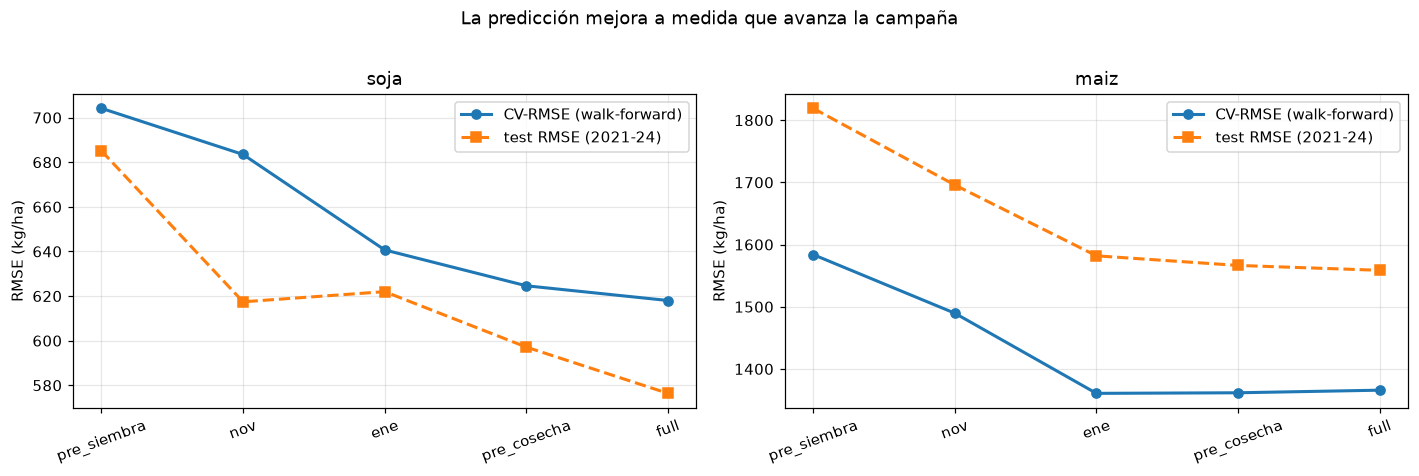

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for ax, cultivo in zip(axes, CULTIVOS):
    s = tabla.loc[cultivo]
    x = range(len(s))
    ax.plot(x, s["CV-RMSE"], "o-", label="CV-RMSE (walk-forward)", lw=2)
    ax.plot(x, s["test RMSE"], "s--", label="test RMSE (2021-24)", lw=2)
    ax.set_xticks(list(x)); ax.set_xticklabels(s.index, rotation=20)
    ax.set_ylabel("RMSE (kg/ha)"); ax.set_title(cultivo)
    ax.grid(alpha=0.3); ax.legend()
plt.suptitle("La predicción mejora a medida que avanza la campaña", y=1.02)
plt.tight_layout(); plt.show()

## 4 — Chequeo de sanidad: ¿mejora monótonamente?

Si el enmascarado está bien hecho, la calidad **no debería empeorar** al avanzar de
pre-siembra a full: cada checkpoint ve todo lo del anterior más información nueva. Una
violación grande sería síntoma de un bug.

Las violaciones chicas pueden ser ruido de semilla, así que se miden con más semillas antes
de darlas por reales.

In [7]:
violaciones = []
for cultivo in CULTIVOS:
    for col in ["CV-RMSE", "test RMSE"]:
        v = tabla.loc[cultivo, col].values
        ck = list(tabla.loc[cultivo].index)
        for i in range(len(v) - 1):
            if v[i + 1] > v[i]:
                violaciones.append({"cultivo": cultivo, "metrica": col,
                                    "de": ck[i], "a": ck[i + 1],
                                    "empeora": v[i + 1] - v[i],
                                    "%": 100 * (v[i + 1] - v[i]) / v[i]})
print(f"tendencia global (pre_siembra -> full):")
for cultivo in CULTIVOS:
    s = tabla.loc[cultivo]
    for col in ["CV-RMSE", "test RMSE"]:
        a, b = s[col].iloc[0], s[col].iloc[-1]
        print(f"  {cultivo:5} {col:10}: {a:8.1f} -> {b:8.1f}   ({100*(a-b)/a:+.1f} %)")
print()
pd.DataFrame(violaciones) if violaciones else print("sin violaciones")

tendencia global (pre_siembra -> full):
  soja  CV-RMSE   :    704.2 ->    618.0   (+12.2 %)
  soja  test RMSE :    685.1 ->    576.4   (+15.9 %)
  maiz  CV-RMSE   :   1583.9 ->   1365.9   (+13.8 %)
  maiz  test RMSE :   1819.0 ->   1558.6   (+14.3 %)



,cultivo,metrica,de,a,empeora,%
0,soja,test RMSE,nov,ene,4.55,0.74
1,maiz,CV-RMSE,ene,pre_cosecha,0.92,0.07
2,maiz,CV-RMSE,pre_cosecha,full,4.17,0.31


In [8]:
# ¿Las violaciones superan el ruido entre semillas?
SEEDS_TEST = [42, 52, 62, 72, 82, 92, 102, 112]

def serie(cultivo, m, metrica):
    p = dict(HP[cultivo]["xgb"]["best_params"])
    ds = datos.prepare(cultivo, momento=m, **BASE)
    if metrica == "CV-RMSE":
        return np.array([ev.cv_score(XGBoostRegressor, {**p, "random_state": s},
                                     ds, n_splits=4) for s in SEEDS_TEST])
    return np.array([ev.metricas(ds.y_test, XGBoostRegressor(**{**p, "random_state": s})
                                 .fit(ds.X_train, ds.y_train).predict(ds.X_test))["rmse"]
                     for s in SEEDS_TEST])

filas = []
for v in violaciones:
    a = serie(v["cultivo"], v["de"], v["metrica"])
    b = serie(v["cultivo"], v["a"], v["metrica"])
    d = b - a                      # >0 = el checkpoint posterior es PEOR
    filas.append({"cultivo": v["cultivo"], "metrica": v["metrica"],
                  "transicion": f"{v['de']} -> {v['a']}",
                  "empeora": d.mean(), "±": d.std(),
                  "sigmas": d.mean() / d.std() if d.std() else np.nan,
                  "semillas": f"{int((d > 0).sum())}/{len(SEEDS_TEST)}"})
pd.DataFrame(filas).set_index(["cultivo", "metrica"])

[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


transicion  empeora    ±  sigmas semillas
cultivo metrica                                                      
soja    test RMSE           nov -> ene     4.22 4.92    0.86      7/8
maiz    CV-RMSE     ene -> pre_cosecha    -0.45 2.85   -0.16      4/8
        CV-RMSE    pre_cosecha -> full     5.97 3.23    1.85      8/8

## 5 — Cuánto aporta el suelo en cada checkpoint

Las capas de suelo son estáticas, así que están disponibles **en todos los checkpoints**,
incluido pre-siembra. La hipótesis agronómica es que pesen más cuanto menos clima observado
haya: si no sabés nada de la campaña, la capacidad de retención de agua del suelo es de lo
poco que te orienta.

In [9]:
filas = []
for cultivo in CULTIVOS:
    for m in datos.CHECKPOINTS:
        r = {}
        for etiqueta, usar in [("sin", False), ("con", True)]:
            kw = dict(BASE); kw["use_suelo"] = usar
            r[etiqueta], r[f"n_{etiqueta}"] = cv(cultivo, momento=m, **kw)
        filas.append({"cultivo": cultivo, "checkpoint": m,
                      "feats": f"{r['n_sin']} -> {r['n_con']}",
                      "sin suelo": r["sin"], "con suelo": r["con"],
                      "mejora %": 100 * (r["sin"] - r["con"]) / r["sin"]})
suelo = pd.DataFrame(filas).set_index(["cultivo", "checkpoint"])
suelo

[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


...

[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


feats  sin suelo  con suelo  mejora %
cultivo checkpoint                                           
soja    pre_siembra  12 -> 25     707.42     704.16      0.46
        nov          41 -> 54     683.54     683.48      0.01
        ene          59 -> 72     637.67     640.69     -0.47
        pre_cosecha  68 -> 81     624.13     624.61     -0.08
        full         78 -> 91     618.46     618.01      0.07
maiz    pre_siembra  12 -> 25   1,676.11   1,583.88      5.50
        nov          41 -> 54   1,506.93   1,489.65      1.15
        ene          59 -> 72   1,373.02   1,360.77      0.89
        pre_cosecha  68 -> 81   1,373.98   1,361.70      0.89
        full         78 -> 91   1,380.59   1,365.87      1.07

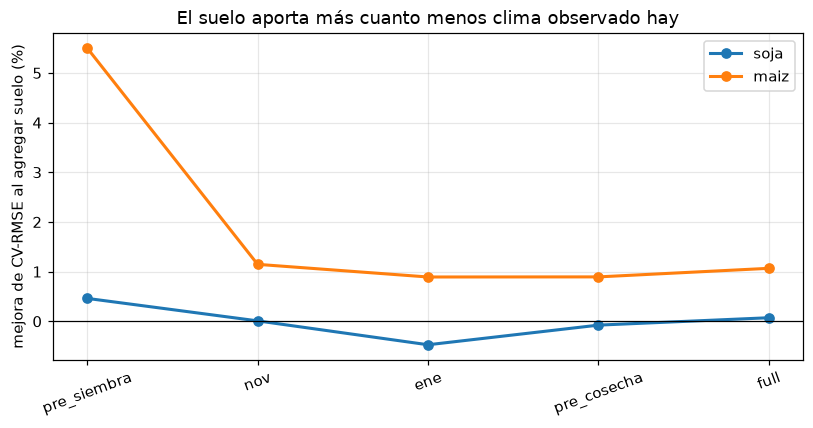

In [10]:
fig, ax = plt.subplots(figsize=(7.5, 4))
for cultivo in CULTIVOS:
    s = suelo.loc[cultivo]
    ax.plot(range(len(s)), s["mejora %"], "o-", lw=2, label=cultivo)
ax.set_xticks(range(len(datos.CHECKPOINTS)))
ax.set_xticklabels(list(datos.CHECKPOINTS), rotation=20)
ax.axhline(0, color="k", lw=0.8)
ax.set_ylabel("mejora de CV-RMSE al agregar suelo (%)")
ax.set_title("El suelo aporta más cuanto menos clima observado hay")
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

## Conclusión

**1. Los checkpoints funcionan.** La regla de mes de corte generaliza los tres momentos que
había a cinco, y los tres viejos (`pre_siembra`, `pre_cosecha`, `full`) devuelven
exactamente las mismas columnas que antes — los resultados ya publicados del nb 08 no se
mueven. Ningún mes futuro se filtra y cada checkpoint contiene al anterior.

**2. La predicción mejora fuerte al avanzar la campaña**, que es el chequeo de sanidad
central: de pre-siembra a full, el test RMSE baja ~16 % en soja y ~14 % en maíz. El modelo
es utilizable desde antes de sembrar, con la precisión que corresponde a esa incertidumbre.

**3. Hay una violación de monotonía real, y tiene sentido agronómico.** En maíz, agregar
marzo (`pre_cosecha` → `full`) **empeora** el CV-RMSE en las 8 semillas, ~1.9 sigmas. No es
un bug del enmascarado: el maíz define su rinde en la ventana Nov–Ene — es literalmente lo
que dice `CRITICAL_MONTHS["maiz"]` en el config — así que el clima posterior aporta features
sin señal causal, que solo suman varianza. Las otras dos violaciones quedan dentro del ruido
(`ene → pre_cosecha` en maíz es 4/8 semillas; `nov → ene` en soja, 7/8 pero a 0.9 sigmas).

> Implicación práctica: para maíz, esperar hasta el final de la campaña no mejora nada
> respecto de enero. La mejor predicción está disponible **meses antes** de la cosecha.

Notar que la violación aparece en CV-RMSE y no en test RMSE, que sí es monótono en maíz: son
regímenes distintos (folds expandidos dentro de train vs. el bloque 2021–24).

**4. El eje inter-campaña ya estaba resuelto.** El momentum EWMA del spec es redundante con
`use_lags`. Queda implementado y con default apagado, documentando el resultado negativo.

**5. El aporte del suelo depende del cultivo, y es menor de lo que sugería el EDA.** En maíz
el patrón esperado se cumple con fuerza: +5.5 % en pre-siembra, cayendo a ~1 % una vez que
entra el clima. En soja, en cambio, **el suelo deja de aportar** (≤0.5 %, con valores
negativos dentro del ruido en los checkpoints intermedios).

La diferencia con el EDA de suelo (`eda_suelo_geografia`, que medía +1.4 % en soja) es que
**ahí no estaban los lags del rinde**. Al sumar `rinde_lag1..3` + `rinde_ma5`, el nivel
histórico del departamento queda capturado directamente, y en soja eso subsume lo que el
suelo aportaba como proxy. En maíz no alcanza: la capacidad de retención de agua sigue
sumando información propia en pre-siembra.

Es el mismo mecanismo que hace redundante al momentum, y conviene tenerlo presente al leer
cualquier ablación de features estructurales: **hay que medirlas contra el modelo completo,
no contra uno sin memoria.**